In [1]:
!git clone https://github.com/AGupta-23/RetinaVision.git
%cd RetinaVision

Cloning into 'RetinaVision'...
remote: Enumerating objects: 61, done.
remote: Total 61 (delta 0), reused 0 (delta 0), pack-reused 61 (from 1)
Receiving objects: 100% (61/61), 88.10 MiB | 35.56 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/kaggle/working/RetinaVision


In [2]:
# Install (Kaggle usually needs this — torchvision's built-in version can be outdated)
!pip install -q grad-cam

import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from src.model import build_model  # your existing module

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model()
model.load_state_dict(torch.load("/kaggle/working/RetinaVision/models/best_model.pth", map_location=device))
model.to(device)
model.eval()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/aptos2019-blindness-detection
/kaggle/input/competitions/aptos2019-blindness-detection/train_images
/kaggle/input/competitions/aptos2019-blindness-detection/test_images


In [5]:
import pandas as pd
misclassified = pd.read_csv("/kaggle/working/RetinaVision/outputs/misclassified_samples.csv")  # adjust filename
print(misclassified.head())

       filename  label  pred      prob  correct                  error_type
0  57469423a012      1     0  0.418956    False  False Negative (missed DR)
1  310c27067ac0      1     0  0.264599    False  False Negative (missed DR)
2  7ad0c4975890      0     1  0.941914    False              False Positive
3  d7e5fe5245e0      0     1  0.706999    False              False Positive
4  5548a7961a3e      1     0  0.291020    False  False Negative (missed DR)


In [6]:
img_id = misclassified.iloc[0]["filename"]
img_path = f"/kaggle/input/competitions/aptos2019-blindness-detection/train_images/{img_id}.png"

print(img_path)

/kaggle/input/competitions/aptos2019-blindness-detection/train_images/57469423a012.png


In [7]:
import numpy as np
from PIL import Image
from src.dataset import preprocess_transform

pil_img = Image.open(img_path).convert("RGB")
np_img = np.array(pil_img)  # <-- convert to ndarray to match what preprocess_transform expects

input_tensor = preprocess_transform(np_img).unsqueeze(0).to(device)

with torch.no_grad():
    logit = model(input_tensor)
    prob = torch.sigmoid(logit).item()
    pred_label = int(prob > 0.5)

print(f"Predicted prob: {prob:.4f} -> {'DR' if pred_label else 'No DR'}")

targets = [BinaryClassifierOutputTarget(pred_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

Predicted prob: 0.4190 -> No DR


In [8]:
import shutil, os

nested_path = "/kaggle/working/RetinaVision/RetinaVision"

if os.path.exists(nested_path):
    shutil.rmtree(nested_path)
    print("Deleted nested duplicate:", nested_path)
else:
    print("Nothing to delete — path not found")

Nothing to delete — path not found


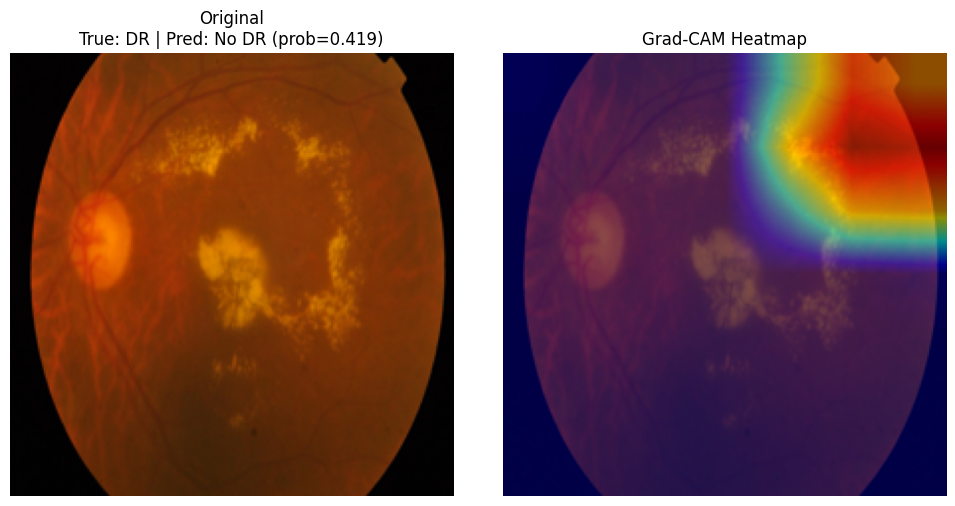

In [9]:
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image

# normalize original image to [0,1] float, resized to match the CAM's 224x224 output
rgb_img_resized = np.array(pil_img.resize((224, 224))) / 255.0
rgb_img_resized = rgb_img_resized.astype(np.float32)

visualization = show_cam_on_image(rgb_img_resized, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_img_resized)
axes[0].set_title(f"Original\nTrue: DR | Pred: {'DR' if pred_label else 'No DR'} (prob={prob:.3f})")
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(f"/kaggle/working/RetinaVision/outputs/gradcam_{img_id}.png", dpi=150)
plt.show()

In [10]:
def run_gradcam(img_id, true_label, save=True):
    """
    Runs the trained model + Grad-CAM on a single image by its APTOS filename ID.
    Returns prob, pred_label, and displays/saves the original vs heatmap comparison.
    """
    img_path = f"/kaggle/input/competitions/aptos2019-blindness-detection/train_images/{img_id}.png"

    # load and preprocess
    pil_img = Image.open(img_path).convert("RGB")
    np_img = np.array(pil_img)
    input_tensor = preprocess_transform(np_img).unsqueeze(0).to(device)

    # prediction
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
        pred_label = int(prob > 0.5)

    # Grad-CAM
    targets = [BinaryClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay
    rgb_img_resized = np.array(pil_img.resize((224, 224))) / 255.0
    rgb_img_resized = rgb_img_resized.astype(np.float32)
    visualization = show_cam_on_image(rgb_img_resized, grayscale_cam, use_rgb=True)

    # plot
    true_str = "DR" if true_label == 1 else "No DR"
    pred_str = "DR" if pred_label == 1 else "No DR"
    correct = "✓ Correct" if true_label == pred_label else "✗ Misclassified"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb_img_resized)
    axes[0].set_title(f"Original — {img_id}\nTrue: {true_str} | Pred: {pred_str} (prob={prob:.3f}) [{correct}]")
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    plt.tight_layout()
    if save:
        plt.savefig(f"/kaggle/working/RetinaVision/outputs/gradcam_{img_id}.png", dpi=150)
    plt.show()

    return {"img_id": img_id, "true": true_label, "pred": pred_label, "prob": prob}

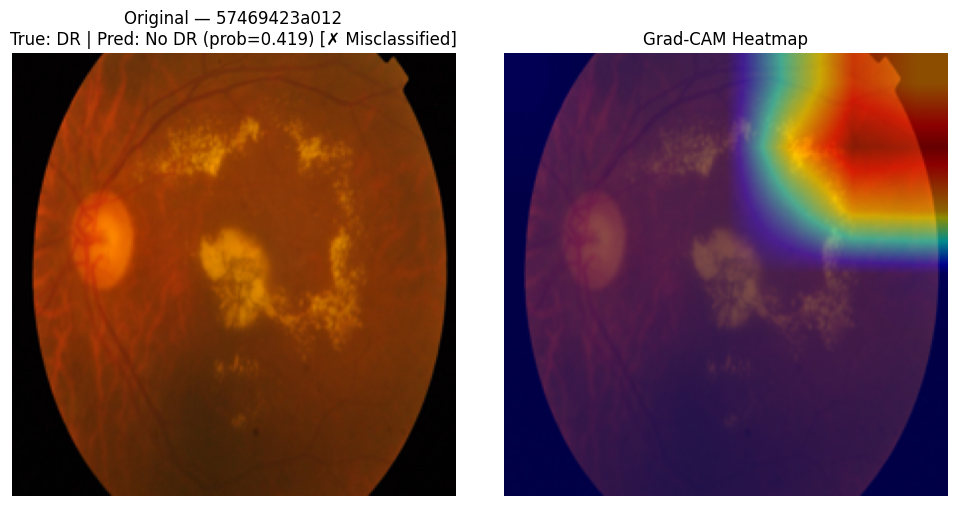

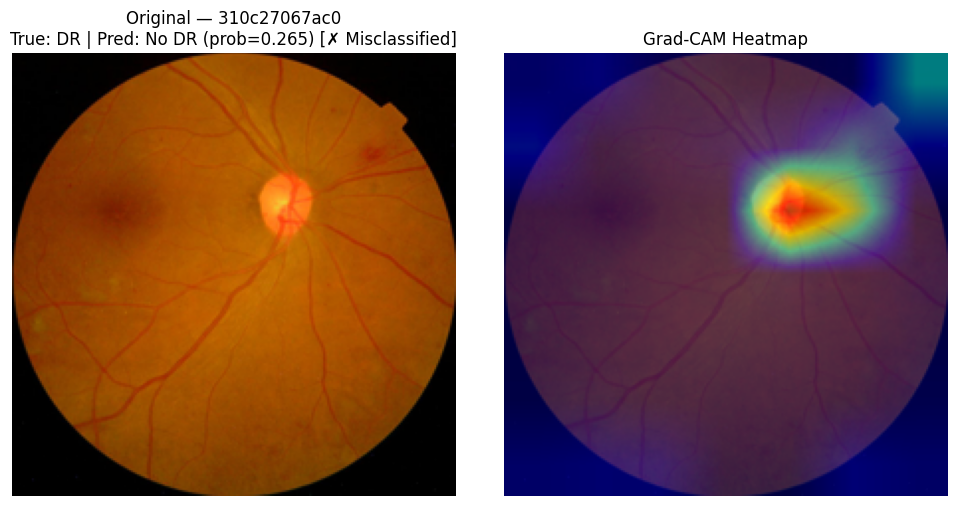

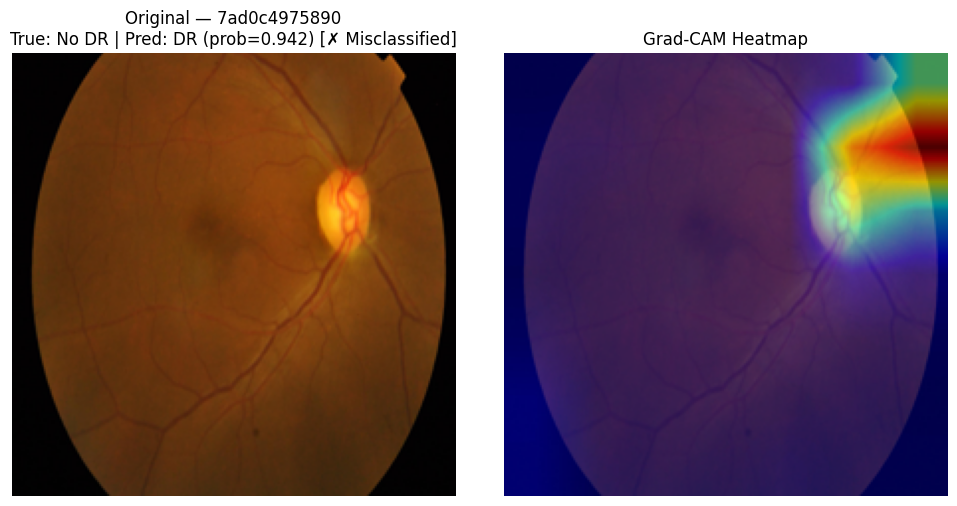

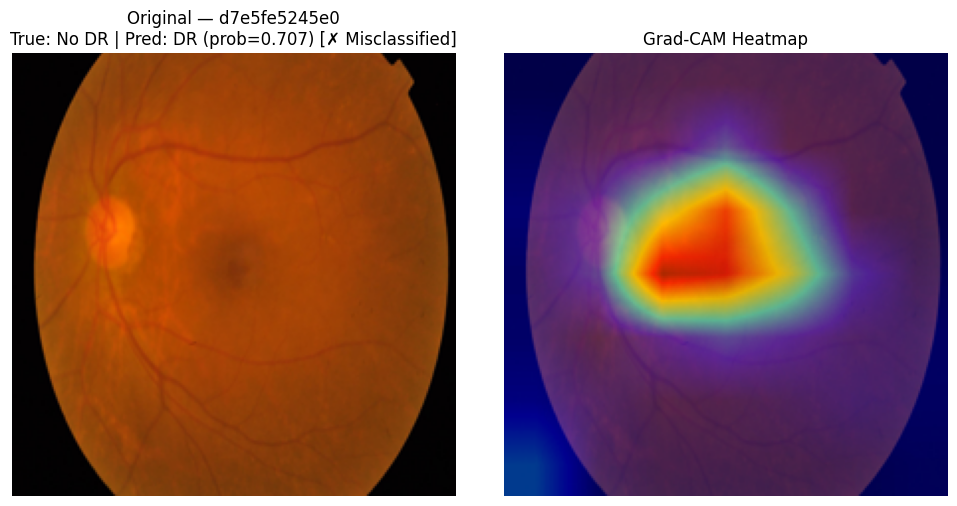

[{'img_id': '57469423a012',
  'true': np.int64(1),
  'pred': 0,
  'prob': 0.4189564287662506},
 {'img_id': '310c27067ac0',
  'true': np.int64(1),
  'pred': 0,
  'prob': 0.26459792256355286},
 {'img_id': '7ad0c4975890',
  'true': np.int64(0),
  'pred': 1,
  'prob': 0.9419148564338684},
 {'img_id': 'd7e5fe5245e0',
  'true': np.int64(0),
  'pred': 1,
  'prob': 0.7069999575614929}]

In [11]:
# pick a mix from your misclassified_samples.csv error_type column,
# plus a correct prediction pulled separately for baseline comparison

selected_rows = [
    misclassified[misclassified["error_type"].str.contains("missed DR")].iloc[0],   # FN #1
    misclassified[misclassified["error_type"].str.contains("missed DR")].iloc[1],   # FN #2
    misclassified[misclassified["error_type"] == "False Positive"].iloc[0],          # FP #1
    misclassified[misclassified["error_type"] == "False Positive"].iloc[1],          # FP #2
]

results = []
for row in selected_rows:
    result = run_gradcam(row["filename"], row["label"])
    results.append(result)

results

In [12]:
import os
for f in sorted(os.listdir("/kaggle/working/RetinaVision/outputs")):
    if f.startswith("gradcam_"):
        print(f)

gradcam_310c27067ac0.png
gradcam_57469423a012.png
gradcam_7ad0c4975890.png
gradcam_d7e5fe5245e0.png


In [13]:
import os
os.listdir("/kaggle/working/RetinaVision/data")

['clean_labels.csv', 'test_split.csv', 'train_split.csv', 'val_split.csv']

In [14]:
print(test_df.columns.tolist())
print(test_df.head())

NameError: name 'test_df' is not defined

In [ ]:
test_df = pd.read_csv("/kaggle/working/RetinaVision/data/test_split.csv")

# candidates: true DR cases, excluding ones already known to be misclassified
misclassified_ids = set(misclassified["filename"])
dr_candidates = test_df[(test_df["label"] == 1) & (~test_df["filename"].isin(misclassified_ids))]

correct_dr_example = None
for img_id in dr_candidates["filename"]:
    result = run_gradcam(img_id, true_label=1, save=False)
    if result["pred"] == 1:
        correct_dr_example = img_id
        break

print("Found correct DR example:", correct_dr_example)

In [ ]:
run_gradcam(correct_dr_example, true_label=1, save=True)